In [121]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score)

In [122]:
#Load Dataset

data1 = pd.read_csv("../Data/CAR DETAILS FROM CAR DEKHO.csv")

print(data1.shape)
data1.head()

(4340, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [123]:
#Dataset Overview

data1.info()

data1.describe()

data1.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [124]:
#Remove Duplicates

print(data1.duplicated().value_counts())

duplicates = (data1[data1.duplicated(keep=False)].sort_values(["name", "year"]))

duplicates.head()

data1 = data1.drop_duplicates()

print(data1.shape)

False    3577
True      763
Name: count, dtype: int64
(3577, 8)


In [125]:
#Feature Engineering

current_year = 2026

data1["car_age"] = current_year - data1["year"]

data1["brand"] = data1["name"].str.split().str[0]

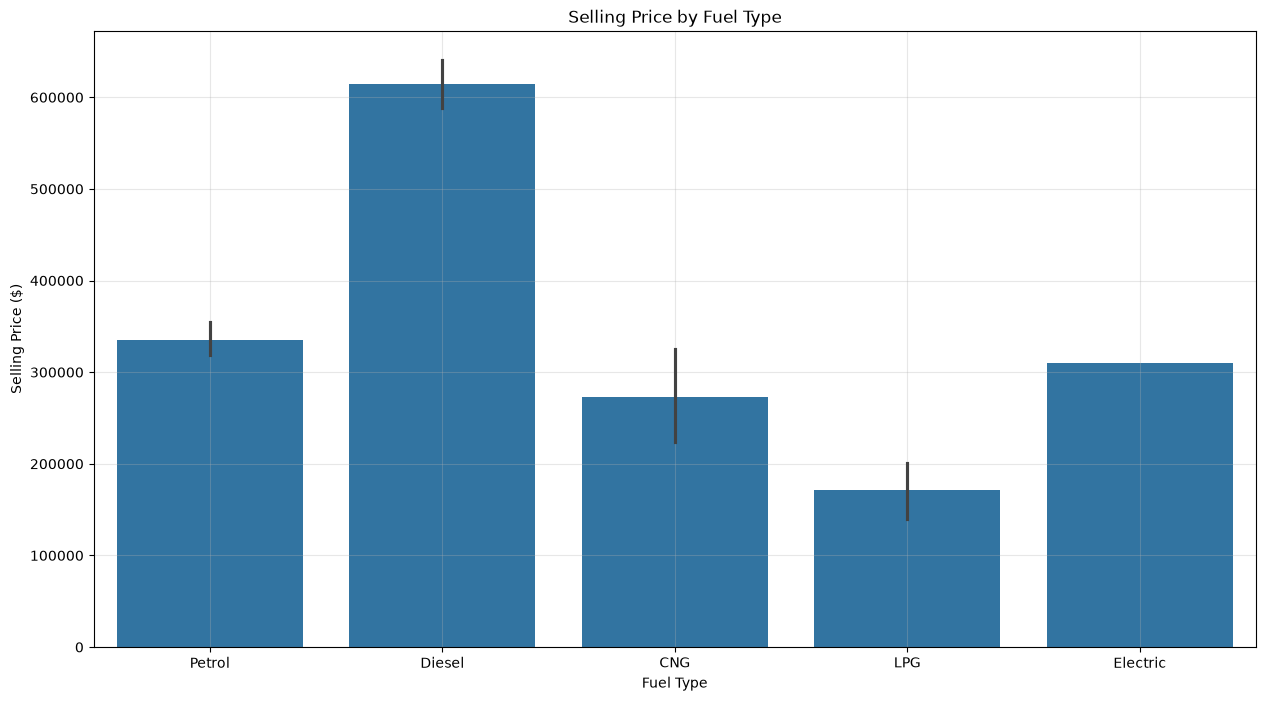

In [126]:
#Exploratory Data Analysis

plt.figure(figsize=(15,8))

sns.barplot(
    data=data1,
    x="fuel",
    y="selling_price")

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price ($)")
plt.grid(alpha=0.3)
plt.savefig("../Images/price_vs_fuel.png", dpi=300, bbox_inches="tight")
plt.show()

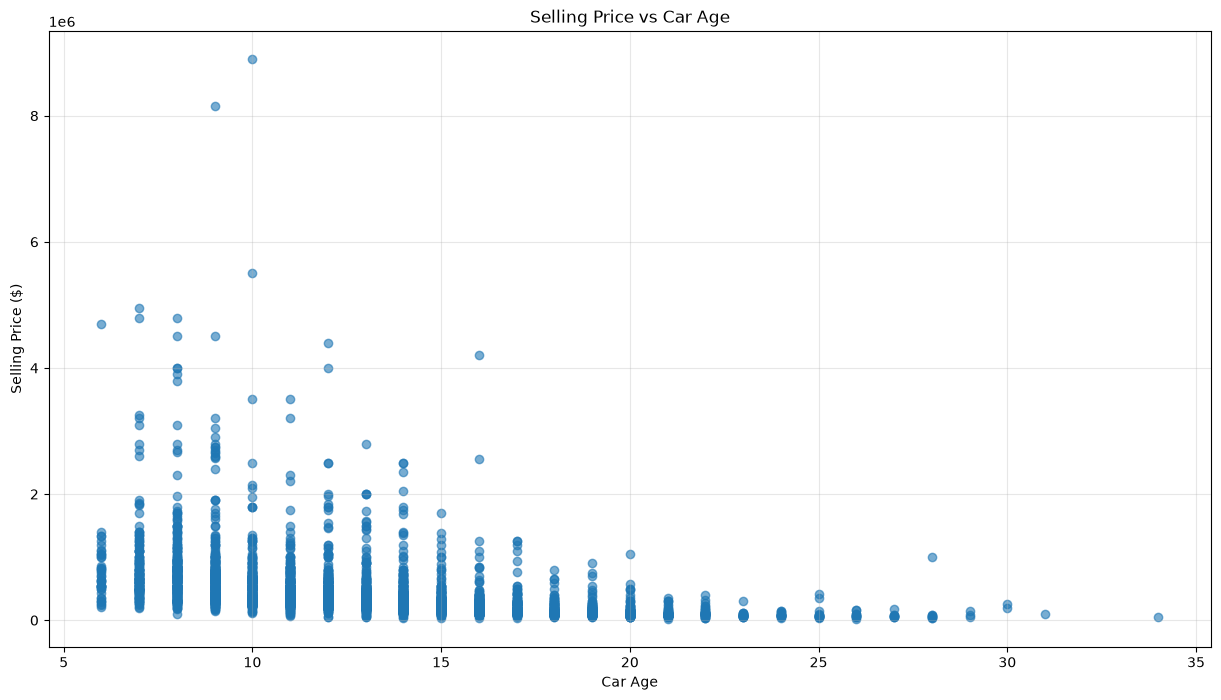

In [127]:
plt.figure(figsize=(15,8))

plt.scatter(
    data1["car_age"],
    data1["selling_price"],
    alpha=0.6)

plt.xlabel("Car Age")
plt.ylabel("Selling Price ($)")
plt.title("Selling Price vs Car Age")
plt.grid(alpha=0.3)
plt.savefig("../Images/price_vs_car_age", dpi=300, bbox_inches="tight")
plt.show()

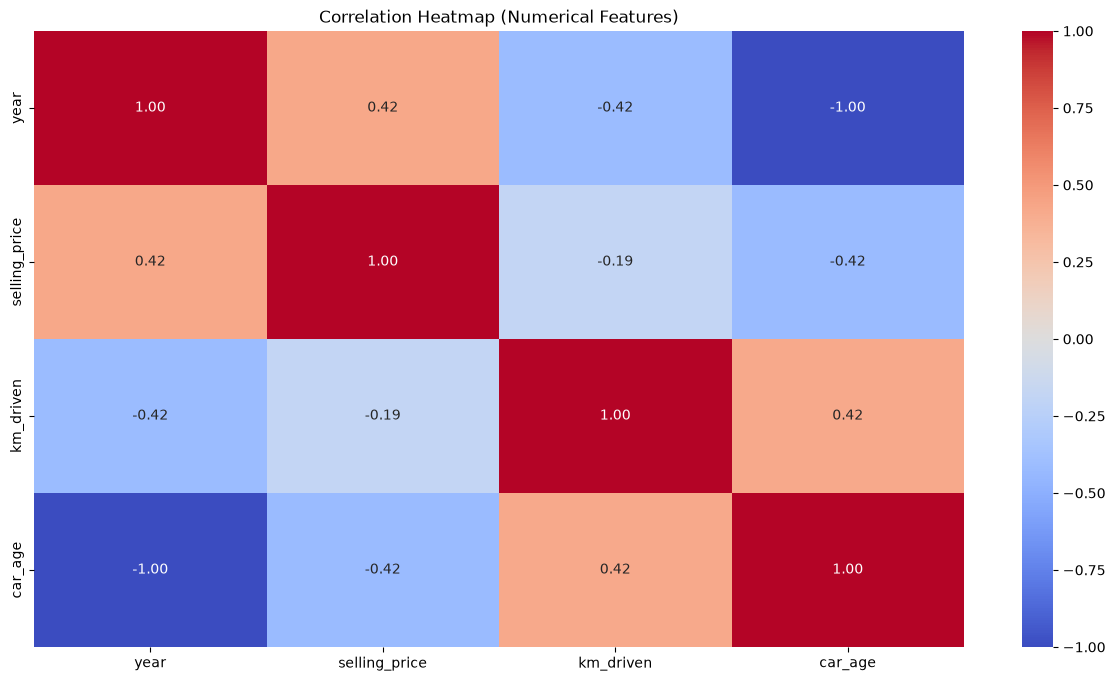

In [128]:
#Correlation Heatmap

numerical_col = data1.select_dtypes(include="number").columns

plt.figure(figsize=(15,8))

sns.heatmap(
    data1[numerical_col].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f")

plt.title("Correlation Heatmap (Numerical Features)")

plt.show()

In [129]:
#Encoding

data1 = data1.drop("name", axis=1)

categorical_col = data1.select_dtypes(include="object").columns

data1 = pd.get_dummies(
    data1,
    columns=categorical_col,
    dtype=int)

C:\Users\TRETEC\AppData\Local\Temp\ipykernel_8552\762469975.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = data1.select_dtypes(include="object").columns


In [130]:
#Train/Test Split

data1["selling_price"] = np.log1p(data1["selling_price"])

x = data1.drop("selling_price", axis=1)
y = data1["selling_price"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42)

In [131]:
#Pipelines

linear_pipeline = Pipeline([("model", LinearRegression())])

rf_pipeline = Pipeline([
    ("model",RandomForestRegressor(
        n_estimators=300,
         max_depth=20,
         min_samples_split=5,
         min_samples_leaf=2,
         random_state=42,
         n_jobs=-1))])
         

In [132]:
#Train Models

linear_pipeline.fit(x_train, y_train)

rf_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](47,)","['year','km_driven','car_age',...,'brand_Toyota','brand_Volkswagen', 'brand_Volvo']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,47
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2


In [133]:
#Evaluate Linear Regression

linear_pred = linear_pipeline.predict(x_test)

linear_pred = np.expm1(linear_pred)
y_true = np.expm1(y_test)

linear_mae = mean_absolute_error(y_true, linear_pred)
linear_rmse = root_mean_squared_error(y_true, linear_pred)
linear_r2 = r2_score(y_true, linear_pred)

print(f"MAE : {linear_mae:.2f}")
print(f"RMSE: {linear_rmse:.2f}")
print(f"R²  : {linear_r2:.3f}")

MAE : 144746.31
RMSE: 287517.32
R²  : 0.743


In [134]:
#Linear Regression Coefficients

coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": linear_pipeline.named_steps["model"].coef_})

coefficients.head()

,Feature,Coefficient
0,year,5.642094e-02
1,km_driven,-6.491055e-07
2,car_age,-5.642094e-02
3,fuel_CNG,-1.358014e-01
4,fuel_Diesel,3.737630e-01


In [135]:
#Evaluate Random Forest

rf_pred = rf_pipeline.predict(x_test)


rf_mae = mean_absolute_error(np.log1p(y_true), rf_pred)
rf_rmse = root_mean_squared_error(np.log1p(y_true), rf_pred)
rf_r2 = r2_score(np.log1p(y_true), rf_pred)

print(f"MAE : {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²  : {rf_r2:.3f}")

MAE : 0.30
RMSE: 0.40
R²  : 0.768


In [136]:
#Cross Validation

linear_cv = cross_val_score(
    linear_pipeline,
    x,
    y,
    cv=5,
    scoring="r2")

rf_cv = cross_val_score(
    rf_pipeline,
    x,
    y,
    cv=5,
    scoring="r2")

In [137]:
#Model Comparison

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R²": [
        linear_r2,
        rf_r2
    ],
    "CV Mean R²": [
        linear_cv.mean(),
        rf_cv.mean()
    ]
})

results.sort_values("R²", ascending=False)

,Model,MAE,RMSE,R²,CV Mean R²
1,Random Forest,0.303706,0.398869,0.767985,0.755538
0,Linear Regression,144746.307524,287517.322355,0.743379,0.764595
